# Diabetes Prediction Using Machine Learning

## Importing Required Libraries

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

## Loading the Dataset

In [30]:
df = pd.read_csv('/content/diabetes.csv')

In [31]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Information

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [33]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Preparing Features and Target Variable

In [34]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

## Splitting Dataset into Training and Testing Data

In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Standardizing the Data

In [36]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Support Vector Machine - Linear Kernel

In [37]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(x_train, y_train)

pred_linear = svm_linear.predict(x_test)

print("Linear Accuracy:", accuracy_score(y_test, pred_linear))

Linear Accuracy: 0.7597402597402597


## Support Vector Machine - RBF Kernel

In [38]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(x_train, y_train)

pred_rbf = svm_rbf.predict(x_test)

print("RBF Accuracy:", accuracy_score(y_test, pred_rbf))

RBF Accuracy: 0.7337662337662337


## Support Vector Machine - Sigmoid Kernel

In [39]:
svm_sigmoid = SVC(kernel='sigmoid')
svm_sigmoid.fit(x_train, y_train)

pred_sigmoid = svm_sigmoid.predict(x_test)

print("Sigmoid Accuracy:", accuracy_score(y_test, pred_sigmoid))

Sigmoid Accuracy: 0.6428571428571429


## Support Vector Machine - Polynomial Kernel

In [40]:
svm_poly = SVC(kernel='poly')
svm_poly.fit(x_train, y_train)

pred_poly = svm_poly.predict(x_test)

print("Polynomial Accuracy:", accuracy_score(y_test, pred_poly))

Polynomial Accuracy: 0.7467532467532467


In [41]:
print(confusion_matrix(y_test, pred_linear))

[[81 18]
 [19 36]]


In [42]:
print(classification_report(y_test, pred_linear))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



## Elbow Method For KNN

In [43]:
error_rate = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)

    error_rate.append(np.mean(pred_i != y_test))

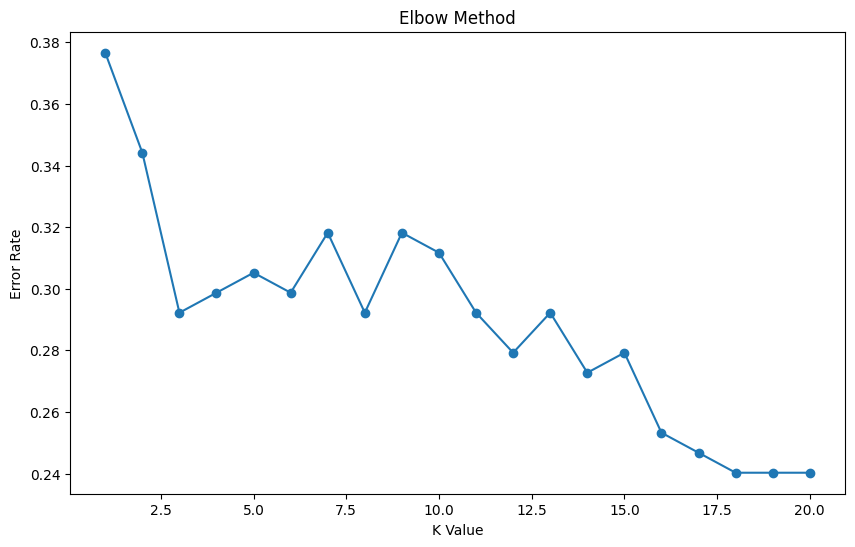

In [44]:
plt.figure(figsize=(10,6))

plt.plot(range(1,21), error_rate, marker='o')

plt.title('Elbow Method')

plt.xlabel('K Value')

plt.ylabel('Error Rate')

plt.show()

## K-Nearest Neighbors (KNN) Model

In [45]:
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(x_train, y_train)

knn_pred = knn.predict(x_test)

In [46]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.6818181818181818


In [47]:
print(confusion_matrix(y_test, knn_pred))

[[78 21]
 [28 27]]


In [48]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76        99
           1       0.56      0.49      0.52        55

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



Model Comparison and Observations

In this project, both Support Vector Machine (SVM) and K-Nearest Neighbors (KNN) algorithms were used to predict diabetes using the Pima Indians Diabetes Dataset.

The KNN model achieved an accuracy of approximately 68%. The model was trained after selecting the optimal K value using the Elbow Method. Although KNN performed reasonably well, its performance was slightly affected by the presence of overlapping data points and sensitivity to neighboring samples.

For SVM, different kernels such as Linear, RBF, Sigmoid, and Polynomial were tested. Among these kernels, the RBF kernel provided better performance compared to the other kernels because it handled non-linear relationships in the dataset more effectively.

The Linear kernel also produced good results, indicating that some level of linear separability exists in the dataset. However, the Sigmoid kernel showed comparatively lower performance, while the Polynomial kernel required more computation and did not significantly improve the accuracy.

Based on the evaluation metrics such as Accuracy Score, Confusion Matrix, and Classification Report, SVM performed better overall than KNN for diabetes prediction. The SVM model was more effective in classifying diabetic and non-diabetic patients accurately.

Therefore, SVM with the RBF kernel can be considered the most suitable model for this dataset.

Conclusion

In this project, machine learning techniques were successfully applied for early diabetes prediction using the Pima Indians Diabetes Dataset.

The dataset was first preprocessed and standardized before training the models. Two classification algorithms, Support Vector Machine (SVM) and K-Nearest Neighbors (KNN), were implemented and evaluated.

For SVM, multiple kernels including Linear, RBF, Sigmoid, and Polynomial were tested to analyze their impact on prediction performance. The KNN model was optimized using the Elbow Method to determine the optimal value of K.

The models were evaluated using Accuracy Score, Confusion Matrix, and Classification Report. From the obtained results, SVM achieved better overall performance compared to KNN, especially with the RBF kernel.

This project demonstrates how machine learning can be effectively used in healthcare applications for disease prediction and early diagnosis. Accurate prediction models can help support medical professionals in identifying diabetic patients at an earlier stage and improve healthcare decision-making.